<a href="https://colab.research.google.com/github/vivekjain060305-coder/Wine_Quality_Prerdiction/blob/main/WQP_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving wine-quality-white-and-red (1).csv to wine-quality-white-and-red (1) (3).csv

Results for 70-30 split
Accuracy: 82.35897435897435
Precision Score: 0.7011494252873564
F1 Score: 0.26180257510729615
AUC Score: 0.8053002222002018


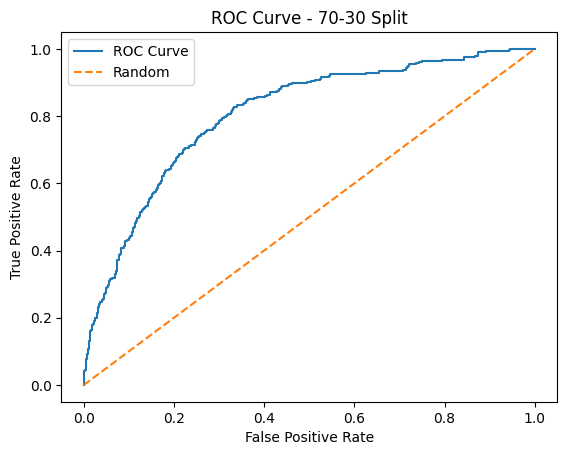

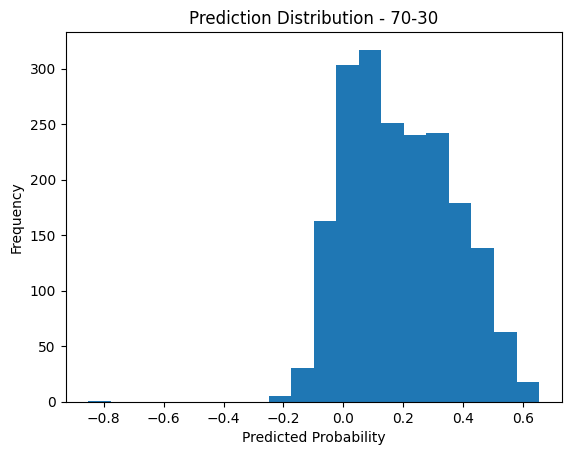


Results for 80-20 split
Accuracy: 82.46153846153847
Precision Score: 0.7450980392156863
F1 Score: 0.25
AUC Score: 0.8232103015957507


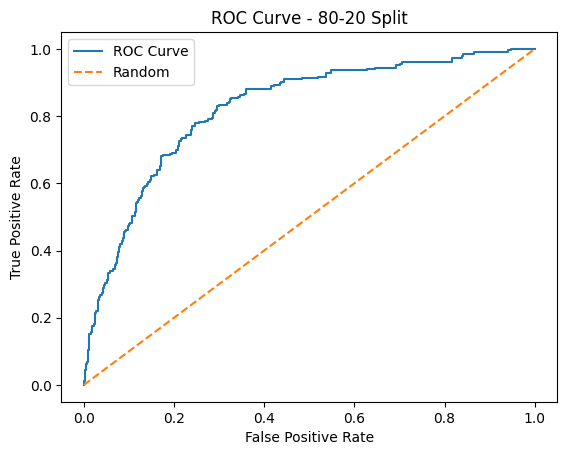

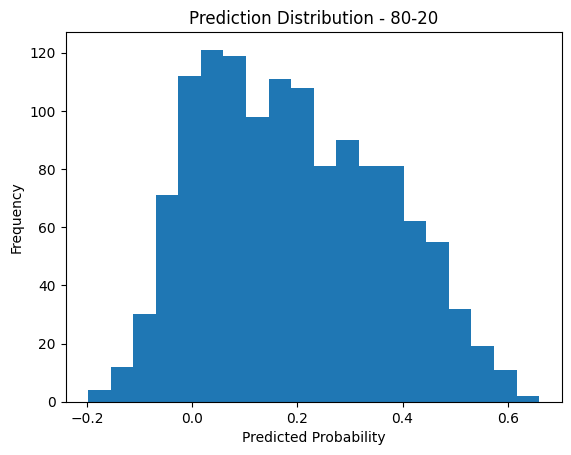

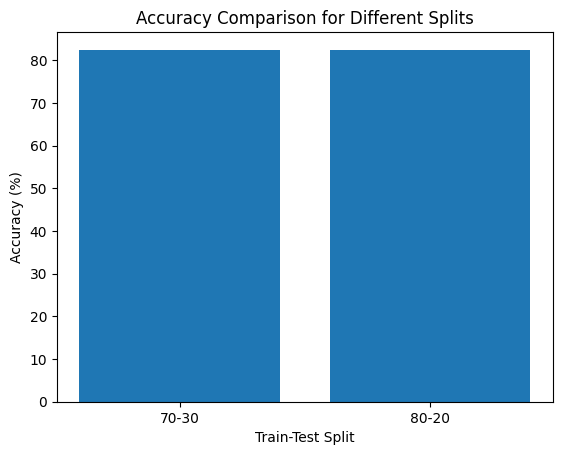

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("wine-quality-white-and-red (1) (2).csv")

# Create binary label
df["quality_label"] = (df["quality"] >= 7).astype(int)

# Convert categorical column
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Features and target
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

splits = {
    "70-30": 0.3,
    "80-20": 0.2
}

accuracy_list = []
split_names = []

for split_name, test_size in splits.items():

    print("\n==============================")
    print(f"Results for {split_name} split")
    print("==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Feature scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prediction
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)

    print("Accuracy:", accuracy)
    print("Precision Score:", precision)
    print("F1 Score:", f1)
    print("AUC Score:", auc)

    accuracy_list.append(accuracy)
    split_names.append(split_name)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

    plt.figure()
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0, 1], [0, 1], linestyle='--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {split_name} Split")
    plt.legend()
    plt.show()

    # Prediction distribution graph
    plt.figure()
    plt.hist(y_pred_prob, bins=20)
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")
    plt.title(f"Prediction Distribution - {split_name}")
    plt.show()


# Accuracy comparison graph
plt.figure()
plt.bar(split_names, accuracy_list)
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison for Different Splits")
plt.show()